# Identifying Keywords About Climate Change

First, we will apply Latent Dirichlet Allocation (LDA) on Integovernmental Panel on Climate Change (IPCC) reports to extract keywords about climate change. LDA is a generative probabilistic model and view each document as random mixtures over latent topics, in which each topic is a probaiblity distribution over a fixed vocabulary. 
LDA can discover topics that the documents contain and the extent to which these topics are included in each document. Thus, it identifies words that are highly present in a large number of IPCC reports. 

## Loading Data

To illustrate the process of LDA, we will first test it on a report from the TCFD. 

In [ ]:
#To be run only the first time to download the libraries
!pip install spacy
!pip install gensim 
!pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')
import re
import numpy as np
from pprint import pprint
import spacy
from pandera.typing import DataFrame, DateTime, Object, Series
import pandera as pa
import gensim 
from nltk.corpus import stopwords
import gensim.corpora as corpora
import pandas as pd

In [45]:

filePath = 'E06 - Climate related risks and opportunities.txt'
report = sum(pd.read_table(filePath).values.tolist(), [])
report = ' '.join(report)

## Preprocessing


In [54]:
def sent_to_words(doc:str):
    return gensim.utils.simple_preprocess(str(doc), deacc=True)

def remove_stopwords(texts):
    stop_words = stopwords.words('english')
    stop_words.extend(['from', 'subject', 're', 'edu', 'use'])
    return [[word for word in gensim.utils.simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]


def make_bigrams(texts):
    bigram = gensim.models.Phrases(texts, min_count=1, threshold=50) # higher threshold fewer phrases.
    bigram_mod = gensim.models.phrases.Phraser(bigram)
    return [bigram_mod[doc] for doc in texts]

In [ ]:
report = [sent_to_words(report)]
report_words = [word for word in report if len(word) > 0]
report_words = remove_stopwords(report_words)
report_words = make_bigrams(report_words)
print(report_words)

## Exploratory Data Analysis

In [69]:
from wordcloud import WordCloud


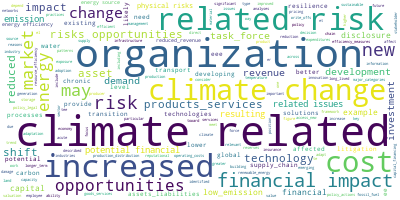

In [70]:
# Join the different processed titles together.
text = ','.join(sum(report_words, []))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(text)
# Visualize the word cloud
wordcloud.to_image()